# Visualising Atomic Orbitals using Python

- The wavefunction of a Hydrogen atom is given by the formula: 

$$
\psi_{nlm}(r,\theta,\phi) = \sqrt{\left(\dfrac{2}{na_{0}} \right)^{3} \dfrac{(n-l-1)!}{2n[(n+l)!]}} e^{-\rho/2} \rho^{l} L_{n-l-1}^{2l+1}(\rho).Y_{lm}(\theta,\phi)
$$

- $\rho = \dfrac{2r}{na_{0}}$

- The wavefunction can be separated into two parts:
    - Radial component: $\sqrt{\left(\dfrac{2}{na_0} \right)^{3} \dfrac{(n-l-1)!}{2n[(n+l)!]}} e^{-\rho/2} \rho^{l} L_{n-l-1}^{2l+1}(\rho)$
    - Angular component: $Y_{lm}(\theta,\phi)$

---

In [231]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math

## Task 1: Defining a function that converts Cartesian to Spherical coordinates

In [232]:
def cartesian_to_spherical(x_values, y_values, z_values): 
    r = np.sqrt(x_values**2+y_values**2+z_values**2)
    th = np.arccos(z_values/r)
    ph = np.arctan2(y_values,x_values)
    return r, th, ph

## Task 2: Defining a function that computes the radial component

- The radial component of a wavefunction is dependent on the quantum numbers n and l, as well as the radius r. Hence, these should be the parameters defined in the function definition 


In [233]:
#Bohr Radius 
a = 1

def radial_function(n_value, l_value, r_value): 
    rho = (2 * r_value) / (n_value * a)
    norm = np.sqrt((2 / (n_value * a))**3 * math.factorial(n_value - l_value - 1) / (2 * n_value * math.factorial(n_value + l_value)))
    laguerre = genlaguerre(n_value - l_value - 1, 2 * l_value + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l_value * laguerre
    return R

## Task 3: Defining a function that computes the angular component 

- The angular component of a wavefunction is dependent on the quantum numbers l and m, as well as the angles theta and phi. Hence, these should be the parameters defined in the function definition 

In [234]:
def angular_function(l_value,m_value, theta_value, phi_value):
    Y = sph_harm_y(l_value, m_value, theta_value, phi_value)
    if m_value == 0:
        return Y
    elif m_value > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

## Task 4: Defining a function that computes the electron probability density

In [235]:
def e_prob_density(radial_part, angular_part): 
    wavefunction = np.abs(radial_part * angular_part)
    e_density = np.abs(wavefunction)**2
    return e_density

---

## Plotting the Atomic Orbitals 

- For each orbital, the quantum numbers n, l and m are first defined before data points for x and z are generated. This is so that the range of values for x and z scales with the quantum number n 

- `np.meshgrid()` is used to generate a 2 dimensional grid of x and z coordinates. This is because the electron density is calculated for each point in space, which is two dimensional in this case

### Task 5: Plotting 1s orbital

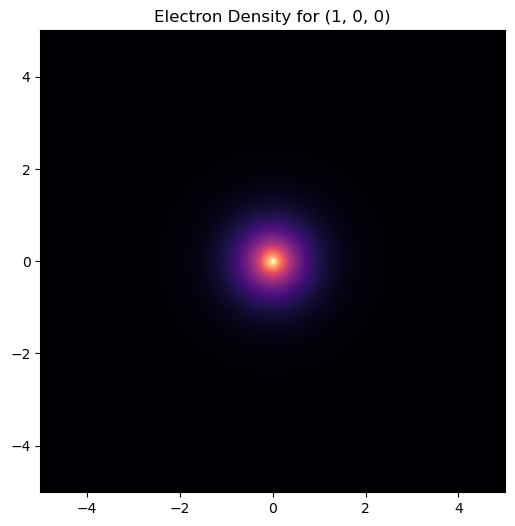

In [236]:
# Defining values for n, l and m
n = 1
l = 0
m = 0

#Generating data points 
x = np.linspace(-5*n,5*n,500)
z = np.linspace(-5*n,5*n,500)

#Forming a 2D grid of x and z coordinates 
X,Z = np.meshgrid(x,z)
Y = 0

#Convert to spherical coords
radius, theta, phi = cartesian_to_spherical(X,Y,Z)

#Calculating the electron density for a 1s orbital
density_1s = e_prob_density(radial_function(n, l, radius), angular_function(l, m, theta, phi))

#Plotting the electron density plot
plt.figure(figsize=(6,6))
plt.pcolormesh(X,Z,density_1s, cmap='magma')
plt.title(f'Electron Density for ({n}, {l}, {m})')
plt.show()

### Task 6: Plotting 2s orbital

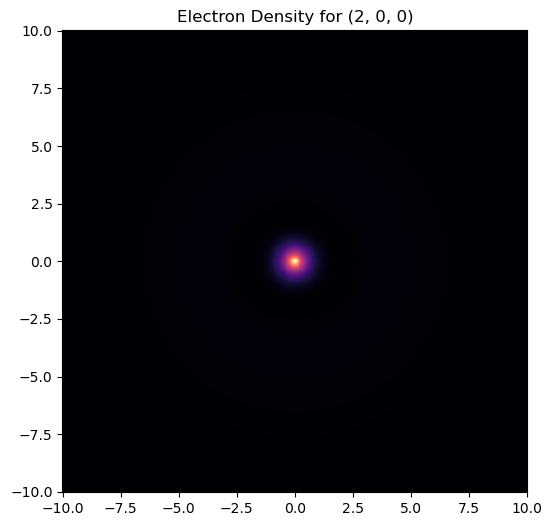

In [237]:
# Defining values for n, l and m
n = 2
l = 0
m = 0

#Generating data points 
x = np.linspace(-5*n,5*n,500)
z = np.linspace(-5*n,5*n,500)

#Forming a 2D grid of x and z coordinates 
X,Z = np.meshgrid(x,z)
Y = 0

#Convert to spherical coords
radius, theta, phi = cartesian_to_spherical(X,Y,Z)

#Calculating the electron density for a 2s orbital
density_2s = e_prob_density(radial_function(n, l, radius), angular_function(l, m, theta, phi))

#Plotting the electron density plot
plt.figure(figsize=(6,6))
plt.pcolormesh(X,Z,density_2s, cmap='magma')
plt.title(f'Electron Density for ({n}, {l}, {m})')
plt.show()

### Task 7: Plotting 2p orbitals

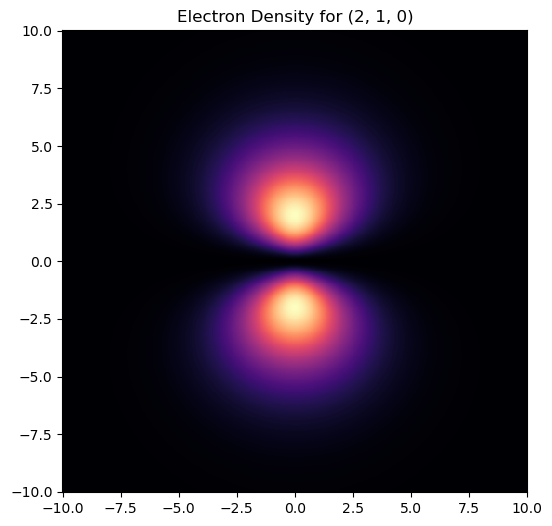

In [240]:
#2pz orbital

# Defining values for n, l and m
n = 2
l = 1
m = 0

#Generating data points 
x = np.linspace(-5*n,5*n,500)
z = np.linspace(-5*n,5*n,500)

#Forming a 2D grid of x and z coordinates 
X,Z = np.meshgrid(x,z)
Y = 0

#Convert to spherical coords
radius, theta, phi = cartesian_to_spherical(X,Y,Z)

#Calculating the electron density for a 2pz orbital
density_2pz = e_prob_density(radial_function(n, l, radius), angular_function(l, m, theta, phi))

plt.figure(figsize=(6,6))
plt.pcolormesh(X,Z,density_2pz, cmap='magma')
plt.title(f'Electron Density for ({n}, {l}, {m})')
plt.show()

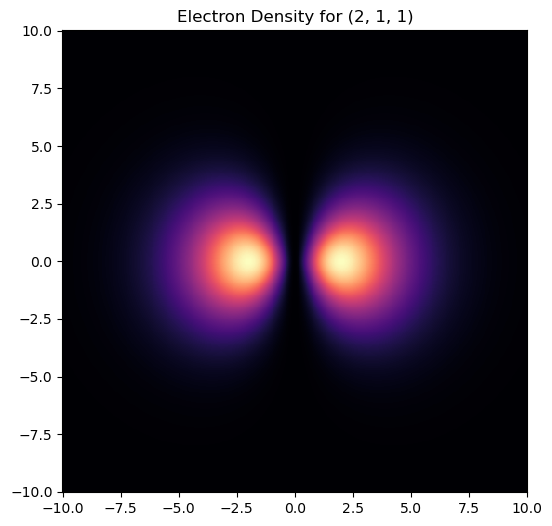

In [241]:
#2px/ 2py orbital

m = 1 

#Calculating the electron density for a 2px/ 2py orbital
density_2px = e_prob_density(radial_function(n, l, radius), angular_function(l, m, theta, phi))

plt.figure(figsize=(6,6))
plt.pcolormesh(X,Z,density_2px, cmap='magma')
plt.title(f'Electron Density for ({n}, {l}, {m})')
plt.show()